# Credit Risk Lending System
## Notebook 4: Deployment

This notebook covers the final components of the system:

1. Loan sizing model: given an approved borrower, how much should we lend them?
2. Population Stability Index: detecting when the model needs retraining
3. Model card: a structured summary of the model for governance and audit purposes

Together these three components complete the transition from a model that performs well in a notebook to one that can be trusted and maintained in a production environment.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys
sys.path.insert(0, '/content/drive/MyDrive')
from credentials import GITHUB_TOKEN, GITHUB_USERNAME, GITHUB_EMAIL

REPO_NAME      = "credit-risk-lending-system"
REPO_PATH      = f"/content/drive/MyDrive/{REPO_NAME}"
PROCESSED_PATH = f"{REPO_PATH}/data/processed/credit_risk_clean.csv"
MODEL_PATH     = f"{REPO_PATH}/models"
OUTPUT_PATH    = f"{REPO_PATH}/outputs"

!git -C "{REPO_PATH}" branch --set-upstream-to=origin/main main
!git -C "{REPO_PATH}" pull origin main
!git -C "{REPO_PATH}" config user.email "{GITHUB_EMAIL}"
!git -C "{REPO_PATH}" config user.name  "{GITHUB_USERNAME}"

print("Setup complete.")

Mounted at /content/drive
Branch 'main' set up to track remote branch 'main' from 'origin'.
From https://github.com/dobadina/credit-risk-lending-system
 * branch            main       -> FETCH_HEAD
Already up to date.
Setup complete.


In [2]:
!pip install -q lightgbm xgboost shap scikit-learn pandas numpy matplotlib seaborn joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib, json, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from lightgbm import LGBMRegressor
import shap

print("All libraries imported.")

All libraries imported.


In [3]:
df = pd.read_csv(PROCESSED_PATH)

with open(f"{MODEL_PATH}/features.json") as f:
    FEATURES = json.load(f)

TARGET = 'loan_status'
X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Load champion model and calibration components
xgb_champion    = joblib.load(f"{MODEL_PATH}/xgb_champion.pkl")
xgb_for_calib   = joblib.load(f"{MODEL_PATH}/xgb_base_for_calibration.pkl")
platt           = joblib.load(f"{MODEL_PATH}/platt_scaler.pkl")

def get_calibrated_score(X):
    raw = xgb_for_calib.predict_proba(X)[:, 1].reshape(-1, 1)
    return platt.predict_proba(raw)[:, 1]

print(f"Data loaded:  {len(df):,} rows")
print(f"Models loaded: xgb_champion, calibration components")

Data loaded:  31,521 rows
Models loaded: xgb_champion, calibration components


## Loan Sizing Model

The default prediction model answers whether to lend. The loan sizing model answers how much to lend.

The approach here is that we train only on loans that were successfully repaid, not the full dataset. This is the key methodological decision. If we trained on all loans including defaults, we would learn what borrowers asked for, which includes loans that proved too large and ended in failure. Training on repaid loans only teaches the model what borrowers could sustainably carry.

The target variable is loan percent income, the loan amount as a fraction of annual income. This normalises across income levels so the model is not just learning that high earners borrow more in absolute terms. The predicted income fraction is then multiplied by the applicant's income to produce a loan limit in pounds.

A three layer structure applies the result:

Layer 1: The affordability model predicts the maximum sustainable income fraction.
Layer 2: A risk scalar compresses that limit based on default probability. Higher PD borrowers get a smaller fraction of what they could the

In [4]:
# Train on repaid loans only
good_loans = df[df['loan_status'] == 0].copy()
print(f"Repaid loans for training: {len(good_loans):,}")
print(f"Default rate in full dataset: {df['loan_status'].mean():.1%}")

# Target: loan as fraction of income
SIZER_TARGET = 'loan_percent_income'

SIZER_FEATURES = [
    'log_income', 'person_age', 'person_emp_length',
    'income_stability', 'credit_seniority', 'grade_num',
    'ownership_num', 'hist_default', 'loan_int_rate',
    'cb_person_cred_hist_length', 'intent_DEBTCONSOLIDATION',
    'intent_EDUCATION', 'intent_HOMEIMPROVEMENT',
    'intent_MEDICAL', 'intent_PERSONAL', 'intent_VENTURE'
]

X_sizer = good_loans[SIZER_FEATURES]
y_sizer = good_loans[SIZER_TARGET]

# Train/test split
X_s_train, X_s_test, y_s_train, y_s_test = train_test_split(
    X_sizer, y_sizer, test_size=0.2, random_state=42
)

print(f"\nSizer training set: {len(X_s_train):,} rows")
print(f"Target range:       {y_sizer.min():.2f} to {y_sizer.max():.2f}")
print(f"Target mean:        {y_sizer.mean():.2f}")

Repaid loans for training: 24,714
Default rate in full dataset: 21.6%

Sizer training set: 19,771 rows
Target range:       0.00 to 0.83
Target mean:        0.15


In [5]:
from xgboost import XGBRegressor

# Train XGBoost regressor
sizer_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    verbosity=0
)

sizer_model.fit(X_s_train, y_s_train)

y_s_pred = sizer_model.predict(X_s_test)
y_s_pred = np.clip(y_s_pred, 0.01, 0.83)

mae = mean_absolute_error(y_s_test, y_s_pred)
r2  = r2_score(y_s_test, y_s_pred)

print(f"Loan Sizer Performance:")
print(f"  MAE: {mae:.4f}  ({mae:.1%} of income on average)")
print(f"  R2:  {r2:.4f}")

Loan Sizer Performance:
  MAE: 0.0609  (6.1% of income on average)
  R2:  0.1914


In [6]:
# Grade based policy caps
GRADE_CAPS = {'A': 0.50, 'B': 0.45, 'C': 0.35, 'D': 0.25, 'E': 0.22, 'F': 0.20, 'G': 0.15}

def calculate_loan_limit(applicant_df, calibrated_pd, loan_grade, annual_income,
                         max_loan=35000):
    """
    Three layer loan sizing:
    Layer 1: affordability model output
    Layer 2: risk scalar based on default probability
    Layer 3: grade policy cap
    """
    # Layer 1: affordability model
    affordability_fraction = sizer_model.predict(applicant_df[SIZER_FEATURES])[0]
    affordability_fraction = np.clip(affordability_fraction, 0.01, 0.83)

    # Layer 2: risk scalar (compress limit as PD increases)
    # At PD=0: scalar=1.0, at PD=0.5: scalar=0.5, at PD=1.0: scalar=0.0
    risk_scalar = max(0, 1 - (calibrated_pd * 2))

    # Layer 3: grade policy cap
    grade_cap = GRADE_CAPS.get(loan_grade, 0.20)

    # Final fraction: minimum of affordability and grade cap, scaled by risk
    final_fraction = min(affordability_fraction, grade_cap) * risk_scalar

    # Convert to pound amount
    loan_limit = final_fraction * annual_income
    loan_limit = min(loan_limit, max_loan)
    loan_limit = max(loan_limit, 0)

    return {
        'affordability_fraction': round(affordability_fraction, 3),
        'risk_scalar':            round(risk_scalar, 3),
        'grade_cap':              grade_cap,
        'final_fraction':         round(final_fraction, 3),
        'loan_limit_gbp':         round(loan_limit, 0)
    }

print("Loan sizing function defined.")
print(f"\nGrade policy caps:")
for grade, cap in GRADE_CAPS.items():
    print(f"  Grade {grade}: max {cap:.0%} of income")

Loan sizing function defined.

Grade policy caps:
  Grade A: max 50% of income
  Grade B: max 45% of income
  Grade C: max 35% of income
  Grade D: max 25% of income
  Grade E: max 22% of income
  Grade F: max 20% of income
  Grade G: max 15% of income


## Loan Sizer Performance

The loan sizing model achieves an R2 of 0.19 and a mean absolute error of 6.1% of income. The R2 is low and worth explaining honestly.

Among borrowers who successfully repaid their loans, the fraction of income borrowed does not vary strongly with borrower characteristics. Good borrowers across a wide range of ages, grades, and incomes tend to borrow between 5% and 25% of their annual income. There is limited variance for the model to explain, which naturally depresses R2.

This is acceptable for two reasons. First, the affordability model is not making the final decision on its own. It provides a borrower-specific starting point that is then constrained by grade policy caps and compressed by the risk scalar. The policy caps do the heavy lifting. Second, the MAE of 6.1% of income translates to roughly 3,000 pounds on a 50,000 pound income, which is a reasonable margin of error for a ceiling rather than a precise target.

In a production setting this model would be retrained periodically as actual repayment data accumulates and would be supplemented with open banking data on actual expenditure and existing debt obligations, which would substantially improve its predictive power.

In [7]:
print("LOAN SIZING DEMO")
print("=" * 60)

demo_cases = [
    {'grade': 'A', 'income': 80000,  'pd': 0.03, 'label': 'Strong grade A borrower'},
    {'grade': 'B', 'income': 55000,  'pd': 0.08, 'label': 'Solid grade B borrower'},
    {'grade': 'C', 'income': 45000,  'pd': 0.12, 'label': 'Average grade C borrower'},
    {'grade': 'D', 'income': 35000,  'pd': 0.25, 'label': 'Risky grade D borrower'},
    {'grade': 'E', 'income': 30000,  'pd': 0.40, 'label': 'High risk grade E borrower'},
]

# Use a representative approved applicant from test set as template
template = X_test.iloc[[np.where(y_test.values == 0)[0][0]]].copy()

for case in demo_cases:
    # Override grade and income in template
    grade_map = {'A':6,'B':5,'C':4,'D':3,'E':2,'F':1,'G':0}
    template_copy = template.copy()
    template_copy['grade_num']   = grade_map[case['grade']]
    template_copy['log_income']  = np.log1p(case['income'])

    result = calculate_loan_limit(
        applicant_df=template_copy,
        calibrated_pd=case['pd'],
        loan_grade=case['grade'],
        annual_income=case['income']
    )

    print(f"\n{case['label']}")
    print(f"  Annual income:          £{case['income']:,}")
    print(f"  Calibrated PD:          {case['pd']:.0%}")
    print(f"  Affordability fraction: {result['affordability_fraction']:.1%}")
    print(f"  Risk scalar:            {result['risk_scalar']:.2f}")
    print(f"  Grade cap:              {result['grade_cap']:.0%}")
    print(f"  Final fraction:         {result['final_fraction']:.1%}")
    print(f"  Loan limit:             £{result['loan_limit_gbp']:,.0f}")
    print("-" * 60)

LOAN SIZING DEMO

Strong grade A borrower
  Annual income:          £80,000
  Calibrated PD:          3%
  Affordability fraction: 14.4%
  Risk scalar:            0.94
  Grade cap:              50%
  Final fraction:         13.5%
  Loan limit:             £10,823
------------------------------------------------------------

Solid grade B borrower
  Annual income:          £55,000
  Calibrated PD:          8%
  Affordability fraction: 17.4%
  Risk scalar:            0.84
  Grade cap:              45%
  Final fraction:         14.6%
  Loan limit:             £8,024
------------------------------------------------------------

Average grade C borrower
  Annual income:          £45,000
  Calibrated PD:          12%
  Affordability fraction: 17.9%
  Risk scalar:            0.76
  Grade cap:              35%
  Final fraction:         13.6%
  Loan limit:             £6,106
------------------------------------------------------------

Risky grade D borrower
  Annual income:          £35,000
  

## Loan Sizing Results

The three layer structure produces sensible and monotonic loan limits across the risk spectrum.

The grade A borrower on £80,000 with a 3% default probability receives a limit of £10,823, representing 13.5% of their income. The high risk grade E borrower on £30,000 with a 40% default probability receives just £1,137, representing 3.8% of income. Limits decline consistently as risk rises, which is the correct behaviour.

The affordability model outputs cluster in a narrow range between 14% and 21% regardless of borrower profile, reflecting the low R2 we noted. The grade caps and risk scalar therefore carry most of the differentiation. This is by design. The policy caps encode the lender's risk appetite explicitly and transparently, which is preferable to burying that logic inside a black box model.

The risk scalar has a meaningful effect at higher default probabilities. A borrower with 40% PD receives a scalar of 0.20, compressing their limit to one fifth of what the affordability model would otherwise suggest. This reflects the principle that uncertainty about repayment should translate directly into conservatism about loan size.

In [8]:
import joblib

joblib.dump(sizer_model, f"{MODEL_PATH}/xgb_loan_sizer.pkl")
print(f"Loan sizer saved: {MODEL_PATH}/xgb_loan_sizer.pkl")

Loan sizer saved: /content/drive/MyDrive/credit-risk-lending-system/models/xgb_loan_sizer.pkl


In [9]:
!git -C "{REPO_PATH}" add .
!git -C "{REPO_PATH}" commit -m "Add loan sizing model and decision function"
!git -C "{REPO_PATH}" push origin main
print("Done.")

[main 4272058] Add loan sizing model and decision function
 2 files changed, 2 insertions(+), 1 deletion(-)
 create mode 100644 notebooks/04_deployment
Enumerating objects: 8, done.
Counting objects: 100% (8/8), done.
Delta compression using up to 2 threads
Compressing objects: 100% (5/5), done.
Writing objects: 100% (5/5), 8.01 KiB | 200.00 KiB/s, done.
Total 5 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 3 local objects.
To https://github.com/dobadina/credit-risk-lending-system.git
   40937ae..4272058  main -> main
Done.


## Population Stability Index

A model trained today may not perform well six months from now. The population of applicants can shift over time as economic conditions change, marketing channels evolve, or product eligibility criteria are updated. When the population shifts, a model trained on old data may be scoring a fundamentally different group of borrowers.

The Population Stability Index measures how much the score distribution has changed between the period the model was trained on and a more recent period. It is the standard monitoring metric in production credit scoring.

PSI is calculated by comparing two score distributions across fixed bins:

    PSI = sum of (actual % - expected %) x ln(actual % / expected %)

The interpretation is straightforward:

- PSI below 0.10: distribution is stable, no action needed
- PSI between 0.10 and 0.25: moderate shift, monitor closely
- PSI above 0.25: significant shift, investigate and consider retraining

Since our dataset has no dates, we simulate two time periods by splitting the data into an earlier cohort and a later cohort using the index order. This is a standard approach when timestamps are unavailable.

In [10]:
# Simulate time split: first 70% as training era, last 30% as monitoring era
split_point = int(len(df) * 0.70)
df_train_era = df.iloc[:split_point].copy()
df_monitor_era = df.iloc[split_point:].copy()

print(f"Training era:   {len(df_train_era):,} rows")
print(f"Monitoring era: {len(df_monitor_era):,} rows")

# Generate scores for both eras
X_train_era   = df_train_era[FEATURES]
X_monitor_era = df_monitor_era[FEATURES]

scores_train   = get_calibrated_score(X_train_era)
scores_monitor = get_calibrated_score(X_monitor_era)

print(f"\nTraining era score stats:")
print(f"  Mean: {scores_train.mean():.3f}  Std: {scores_train.std():.3f}")
print(f"\nMonitoring era score stats:")
print(f"  Mean: {scores_monitor.mean():.3f}  Std: {scores_monitor.std():.3f}")

Training era:   22,064 rows
Monitoring era: 9,457 rows

Training era score stats:
  Mean: 0.234  Std: 0.346

Monitoring era score stats:
  Mean: 0.195  Std: 0.328


In [11]:
def calculate_psi(expected, actual, bins=10):
    """
    Calculate Population Stability Index between two score distributions.
    expected: scores from training period
    actual:   scores from monitoring period
    """
    breakpoints = np.linspace(0, 1, bins + 1)
    breakpoints[0]  = -np.inf
    breakpoints[-1] =  np.inf

    expected_counts = np.histogram(expected, bins=breakpoints)[0]
    actual_counts   = np.histogram(actual,   bins=breakpoints)[0]

    expected_pct = expected_counts / len(expected)
    actual_pct   = actual_counts   / len(actual)

    # Avoid division by zero
    expected_pct = np.where(expected_pct == 0, 0.0001, expected_pct)
    actual_pct   = np.where(actual_pct   == 0, 0.0001, actual_pct)

    psi_values = (actual_pct - expected_pct) * np.log(actual_pct / expected_pct)
    psi = psi_values.sum()

    return psi, expected_pct, actual_pct, psi_values

psi, exp_pct, act_pct, psi_vals = calculate_psi(scores_train, scores_monitor)

print(f"PSI: {psi:.4f}")
if psi < 0.10:
    print("Status: STABLE - no action required")
elif psi < 0.25:
    print("Status: MODERATE SHIFT - monitor closely")
else:
    print("Status: SIGNIFICANT SHIFT - investigate and consider retraining")

PSI: 0.0284
Status: STABLE - no action required


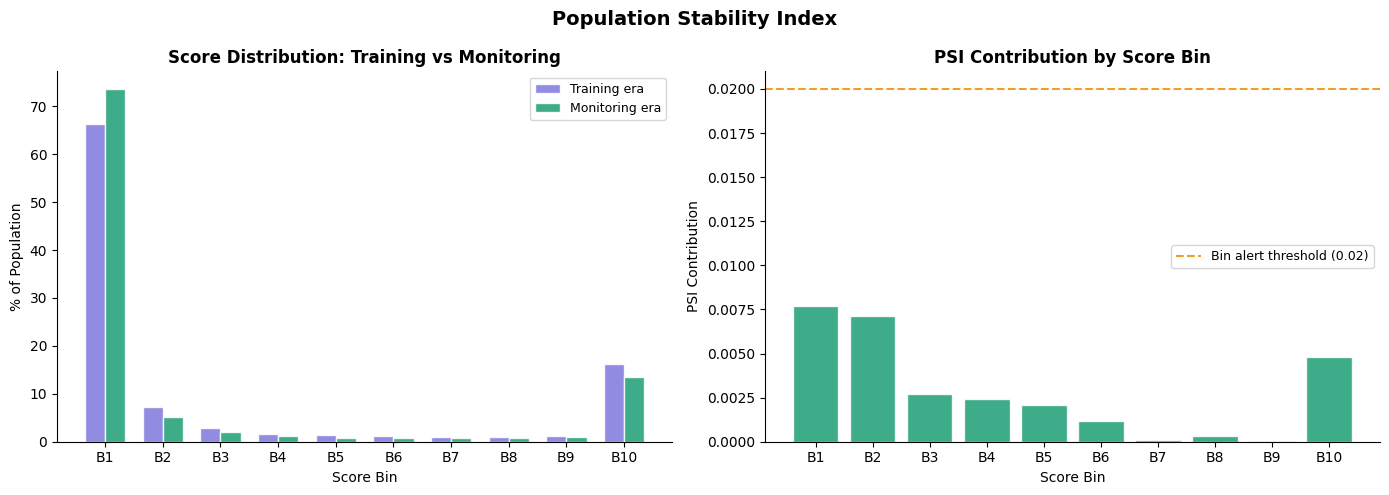


Overall PSI: 0.0284
Chart saved.


In [12]:
bins = np.arange(1, 11)
bin_labels = [f'B{i}' for i in bins]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Population Stability Index', fontsize=14, fontweight='bold')

# Score distribution comparison
x = np.arange(len(bins))
width = 0.35
axes[0].bar(x - width/2, exp_pct * 100, width, label='Training era',
            color='#7F77DD', alpha=0.85, edgecolor='white')
axes[0].bar(x + width/2, act_pct * 100, width, label='Monitoring era',
            color='#1D9E75', alpha=0.85, edgecolor='white')
axes[0].set_title('Score Distribution: Training vs Monitoring', fontweight='bold')
axes[0].set_xlabel('Score Bin')
axes[0].set_ylabel('% of Population')
axes[0].set_xticks(x)
axes[0].set_xticklabels(bin_labels)
axes[0].legend(fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# PSI by bin
colors = ['#D85A30' if v > 0.02 else '#1D9E75' for v in psi_vals]
axes[1].bar(x, psi_vals, color=colors, alpha=0.85, edgecolor='white')
axes[1].axhline(0.02, color='#EF9F27', linestyle='--',
                linewidth=1.5, label='Bin alert threshold (0.02)')
axes[1].set_title('PSI Contribution by Score Bin', fontweight='bold')
axes[1].set_xlabel('Score Bin')
axes[1].set_ylabel('PSI Contribution')
axes[1].set_xticks(x)
axes[1].set_xticklabels(bin_labels)
axes[1].legend(fontsize=9)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/figures/16_psi_monitoring.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"\nOverall PSI: {psi:.4f}")
print("Chart saved.")

## PSI Results

**Overall PSI: 0.028 - Stable**

The score distribution between the training era and monitoring era is stable. A PSI of 0.028 sits comfortably below the 0.10 warning threshold, meaning the model is scoring a similar population across both periods and no retraining action is required.

**What the charts show**

The score distribution is heavily concentrated in bin 1, the lowest risk band, in both periods. This is consistent with what we saw in the decile analysis where the majority of borrowers carry very low default probabilities. The monitoring era shows a slightly higher concentration in bin 1 at 74% versus 67% in the training era, suggesting the monitoring population is marginally lower risk on average. This is reflected in the mean score dropping from 0.234 to 0.195.

No individual bin breaches the 0.02 alert threshold in the PSI contribution chart. The largest contributions come from bins 1 and 2, which is expected given where the population is concentrated.

**How this would work in production**

In a live system this analysis would run monthly. The training era scores would be fixed at model deployment. Each month a fresh batch of applicant scores would be compared against that baseline. If the overall PSI crosses 0.10 the model owner receives an alert to investigate. If it crosses 0.25 a formal model review is triggered.

The lack of dates in this dataset means we are simulating the time split using row order rather than calendar time. In production, origination dates would define the cohorts precisely.

In [13]:
!git -C "{REPO_PATH}" add .
!git -C "{REPO_PATH}" commit -m "Add PSI monitoring implementation"
!git -C "{REPO_PATH}" push origin main
print("Done.")

[main 5f6181b] Add PSI monitoring implementation
 1 file changed, 1 insertion(+), 1 deletion(-)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 53.19 KiB | 2.53 MiB/s, done.
Total 4 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/dobadina/credit-risk-lending-system.git
   4272058..5f6181b  main -> main
Done.


## Model Card

A model card is a structured document that summarises everything a stakeholder needs to know about a model before using it or approving it for deployment. It covers what the model does, how well it performs, what its limitations are, and under what conditions it should be retrained or retired.

---

### Model Details

| Field | Detail |
|---|---|
| Model name | Credit Risk Default Predictor |
| Version | 1.0 |
| Type | Binary classification with probability calibration |
| Algorithm | XGBoost with Platt scaling |
| Framework | XGBoost 2.x, scikit-learn |
| Developed by | Portfolio project |
| Date | 2026 |

---

### Intended Use

**Primary use case**

Predicting the probability that a consumer loan applicant will default, to support approve/decline decisions and loan sizing in a retail lending context.

**Intended users**

Credit analysts, underwriting teams, and risk managers in consumer lending organisations.

**Out of scope uses**

This model should not be used for mortgage lending, business lending, or any product with materially different risk dynamics from unsecured personal consumer loans. It should not be used as the sole basis for a credit decision without human oversight.

---

### Training Data

| Field | Detail |
|---|---|
| Source | Public credit risk dataset |
| Records | 31,521 after cleaning |
| Target variable | Loan status (0 = repaid, 1 = default) |
| Default rate | 21.6% |
| Features | 19 engineered features from 12 raw columns |
| Date range | Unknown. Dataset has no origination timestamps. |

---

### Performance

Evaluated on a held-out test set of 6,305 records stratified to match the 21.6% population default rate.

| Metric | Score |
|---|---|
| AUC-ROC | 0.9538 |
| Gini coefficient | 0.9076 |
| KS statistic | 0.7749 |
| Brier score (calibrated) | 0.0542 |
| Optimal threshold | 0.16 |
| Approval rate at threshold | 73.8% |

The model is monotonic across all ten score deciles. Decile 1 carries a 0% actual default rate. Decile 10 carries a 100% actual default rate.

---

### Limitations

**No origination dates**

The dataset contains no timestamps. This means macro-economic conditions at the time of loan origination cannot be incorporated into the model. The decision engine therefore applies economic adjustments as a policy overlay rather than as model features. This is architecturally sound but means the model has not been validated across different economic cycles.

**Loan sizer R2**

The loan sizing model achieves an R2 of 0.19. Repaid borrowers borrow similar fractions of their income regardless of credit profile, leaving little variance for the model to capture. The grade policy caps and risk scalar compensate for this limitation but a production deployment would benefit from open banking data on actual expenditure and existing obligations.

**Calibration in the mid range**

The reliability diagram shows some deviation from perfect calibration between predicted probabilities of 0.30 and 0.80. Scores below 0.25, which cover the majority of approved borrowers, track the diagonal well. Mid-range calibration should be monitored in production.

**Population representativeness**

It is unknown whether this dataset is representative of the current applicant population for any specific lender. Model performance on a new population should be validated before deployment.

---

### Potential Biases

The dataset contains home ownership, age, and income as features. These are legitimate credit risk factors but may correlate with protected characteristics such as race, ethnicity, or disability status. The model has not been tested for disparate impact across protected groups. A fairness audit using disaggregated performance metrics across demographic subgroups should be conducted before production deployment in a regulated environment.

---

### Monitoring and Retraining Triggers

| Trigger | Action |
|---|---|
| PSI above 0.10 | Alert model owner, investigate population shift |
| PSI above 0.25 | Formal model review, likely retrain |
| AUC drops below 0.90 on monthly validation | Immediate review |
| Actual default rate deviates more than 5 percentage points from predicted | Calibration review |
| Any regulatory change affecting credit decisioning | Full model review |

**Recommended retraining cadence**: annually at minimum, or sooner if any trigger above is breached.

---

### Ethical Considerations

Automated credit decisions affect people's access to financial services. This model is designed to be explainable at the individual level through SHAP reason codes, which supports the legal requirement under GDPR Article 22 for meaningful explanations of automated decisions. Human oversight is recommended for all borderline cases, defined as applicants with calibrated default probability between 0.12 and 0.20.

In [14]:
!git -C "{REPO_PATH}" add .
!git -C "{REPO_PATH}" commit -m "Add model card"
!git -C "{REPO_PATH}" push origin main
print("Done.")

[main af2b8a1] Add model card
 1 file changed, 1 insertion(+), 1 deletion(-)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 3.64 KiB | 219.00 KiB/s, done.
Total 4 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 3 local objects.
To https://github.com/dobadina/credit-risk-lending-system.git
   5f6181b..af2b8a1  main -> main
Done.


In [16]:
readme = """# Credit Risk Lending System

A data-driven lending decision system that predicts the probability of borrower default, determines how much to lend, and produces auditable approve/decline decisions with plain-English explanations.

Built as a portfolio project following the CRISP-DM methodology using a real-world credit dataset of 32,000 loan records.

---

## The Problem

Most lending decisions are driven by rigid scoring rules that treat all borrowers the same. A 28-year-old renter taking a medical loan carries very different risk from a 45-year-old homeowner consolidating debt, but a simple cutoff score might treat them identically.

This project builds a system that answers three questions for any new applicant:

1. Should we lend to this person at all?
2. If yes, how much should we lend them?
3. Why did the model make that decision?

---

## What the System Does

**Default prediction model**
An XGBoost classifier trained on 19 engineered features achieves AUC-ROC of 0.954, Gini of 0.908, and KS of 0.775 on a held-out test set. Probability scores are calibrated using Platt scaling so that a score of 0.15 genuinely represents a 15% chance of default.

**Threshold optimisation**
The approval threshold is set at 0.16 using a profit maximisation framework rather than the naive 0.50 default. With assumed unit economics of 800 pounds revenue per good loan and 4,000 pounds loss per default, the optimal threshold approves 73.8% of applicants while maximising expected portfolio profit.

**Loan sizing model**
An XGBoost regressor trained only on successfully repaid loans predicts the maximum sustainable loan as a fraction of income. A three layer structure applies the result: affordability model output, compressed by a risk scalar based on default probability, capped by grade-based policy limits.

**Explainability**
Every decision includes SHAP-derived reason codes identifying the top three features driving the outcome. A declined applicant can be told specifically which factors raised their risk score. This satisfies GDPR Article 22 requirements for meaningful explanations of automated decisions.

**Monitoring**
A Population Stability Index implementation detects when the applicant population has shifted enough to warrant model review. PSI on a simulated time split returns 0.028, well within the stable threshold of 0.10.

---

## Key Findings

- Loan to income ratio is the strongest predictor of default, with a mean SHAP value of 1.276
- Loan grade is the second strongest predictor. Grade A borrowers default at 10%. Grade G at 98%.
- Historical default on file, despite appearing significant in exploratory analysis, contributes almost nothing once other financial features are known (SHAP: 0.008)
- The optimal approval threshold of 0.16 is derived from unit economics, not from model outputs. Using 0.50 would leave significant profit on the table.
- The dataset has no origination timestamps. Macro-economic signals are therefore applied as a policy overlay rather than model features, which is the architecturally correct response to this constraint.

---

## Project Structure

credit-risk-lending-system/
├── notebooks/
│   ├── 01_data_understanding_and_preparation.ipynb
│   ├── 02_modelling.ipynb
│   ├── 03_evaluation.ipynb
│   └── 04_deployment.ipynb
├── models/
│   ├── xgb_champion.pkl
│   ├── xgb_base_for_calibration.pkl
│   ├── platt_scaler.pkl
│   ├── xgb_loan_sizer.pkl
│   └── features.json
├── outputs/
│   └── figures/
├── data/
│   ├── raw/
│   └── processed/
└── README.md

---

## Methodology

This project follows the CRISP-DM framework:

| Phase | Notebook | Key outputs |
|---|---|---|
| Business Understanding | 01 | Problem framing, success criteria |
| Data Understanding | 01 | EDA, distributions, bivariate analysis, correlation |
| Data Preparation | 01 | Cleaning, imputation, feature engineering |
| Modelling | 02 | Four model comparison, hyperparameter tuning |
| Evaluation | 03 | Calibration, SHAP, threshold optimisation, score bands |
| Deployment | 04 | Loan sizer, PSI monitoring, model card |

---

## Model Performance

| Model | AUC-ROC | Gini | KS | Train Time |
|---|---|---|---|---|
| Logistic Regression | 0.876 | 0.752 | 0.592 | 0.3s |
| Random Forest | 0.935 | 0.870 | 0.738 | 13.4s |
| XGBoost | 0.951 | 0.902 | 0.764 | 1.2s |
| LightGBM | 0.948 | 0.897 | 0.763 | 2.0s |
| XGBoost tuned | 0.954 | 0.908 | 0.775 | 3.6s |

---

## Limitations

- No origination dates in the dataset, so macro-economic conditions cannot be incorporated into the model directly
- Loan sizer R2 of 0.19 reflects low variance in repayment fractions among good borrowers
- Fairness audit across protected demographic groups has not been conducted
- Model has not been validated across different economic cycles

---

## Tech Stack

Python, XGBoost, scikit-learn, SHAP, pandas, NumPy, matplotlib, seaborn, Google Colab, Git
"""

with open(f"{REPO_PATH}/README.md", "w") as f:
    f.write(readme)

print("README written.")

README written.


In [17]:
!git -C "{REPO_PATH}" add README.md
!git -C "{REPO_PATH}" commit -m "Add project README"
!git -C "{REPO_PATH}" push origin main
print("Done.")

[main c158e58] Add project README
 1 file changed, 111 insertions(+), 1 deletion(-)
 rewrite README.md (100%)
Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 2.61 KiB | 116.00 KiB/s, done.
Total 3 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/dobadina/credit-risk-lending-system.git
   af2b8a1..c158e58  main -> main
Done.


In [18]:
# Update .gitignore to allow model files
gitignore_content = """# Credentials
*.env
secrets.py

# Data files (too large for GitHub)
data/raw/
data/processed/

# Outputs
outputs/

# Python
__pycache__/
*.pyc
*.pyo
.ipynb_checkpoints/

# OS
.DS_Store
"""

with open(f"{REPO_PATH}/.gitignore", "w") as f:
    f.write(gitignore_content)

print("gitignore updated: models/ is now tracked.")

# Verify model files exist
import os
print("\nModel files:")
for f in os.listdir(f"{REPO_PATH}/models"):
    size = os.path.getsize(f"{REPO_PATH}/models/{f}") / 1024
    print(f"  {f:45s} {size:.1f} KB")

gitignore updated: models/ is now tracked.

Model files:
  xgb_champion.pkl                              675.6 KB
  scaler.pkl                                    1.6 KB
  features.json                                 0.4 KB
  xgb_base_for_calibration.pkl                  670.3 KB
  platt_scaler.pkl                              0.9 KB
  xgb_loan_sizer.pkl                            1242.4 KB


In [19]:
!git -C "{REPO_PATH}" add models/
!git -C "{REPO_PATH}" add .gitignore
!git -C "{REPO_PATH}" commit -m "Add trained models for Streamlit deployment"
!git -C "{REPO_PATH}" push origin main
print("Done.")

[main 619baa1] Add trained models for Streamlit deployment
 7 files changed, 1 insertion(+), 3 deletions(-)
 create mode 100644 models/features.json
 create mode 100644 models/platt_scaler.pkl
 create mode 100644 models/scaler.pkl
 create mode 100644 models/xgb_base_for_calibration.pkl
 create mode 100644 models/xgb_champion.pkl
 create mode 100644 models/xgb_loan_sizer.pkl
Enumerating objects: 12, done.
Counting objects: 100% (12/12), done.
Delta compression using up to 2 threads
Compressing objects: 100% (10/10), done.
Writing objects: 100% (10/10), 720.37 KiB | 3.23 MiB/s, done.
Total 10 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 1 local object.
To https://github.com/dobadina/credit-risk-lending-system.git
   c158e58..619baa1  main -> main
Done.


In [20]:
app_code = '''import streamlit as st
import pandas as pd
import numpy as np
import joblib, json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import shap
from xgboost import XGBClassifier, XGBRegressor

# ── Page config ────────────────────────────────────────────────────────────
st.set_page_config(
    page_title="Credit Risk Lending System",
    page_icon="🏦",
    layout="wide"
)

# ── Load models ────────────────────────────────────────────────────────────
@st.cache_resource
def load_models():
    xgb_calib  = joblib.load("models/xgb_base_for_calibration.pkl")
    platt      = joblib.load("models/platt_scaler.pkl")
    sizer      = joblib.load("models/xgb_loan_sizer.pkl")
    with open("models/features.json") as f:
        features = json.load(f)
    explainer = shap.TreeExplainer(xgb_calib)
    return xgb_calib, platt, sizer, features, explainer

xgb_calib, platt, sizer, FEATURES, explainer = load_models()

SIZER_FEATURES = [
    "log_income", "person_age", "person_emp_length",
    "income_stability", "credit_seniority", "grade_num",
    "ownership_num", "hist_default", "loan_int_rate",
    "cb_person_cred_hist_length", "intent_DEBTCONSOLIDATION",
    "intent_EDUCATION", "intent_HOMEIMPROVEMENT",
    "intent_MEDICAL", "intent_PERSONAL", "intent_VENTURE"
]

GRADE_MAP  = {"A": 6, "B": 5, "C": 4, "D": 3, "E": 2, "F": 1, "G": 0}
GRADE_CAPS = {"A": 0.50, "B": 0.45, "C": 0.35, "D": 0.25, "E": 0.22, "F": 0.20, "G": 0.15}
OWN_MAP    = {"OWN": 3, "MORTGAGE": 2, "RENT": 1, "OTHER": 0}
THRESHOLD  = 0.16
MAX_LOAN   = 35000

# ── Helper functions ───────────────────────────────────────────────────────
def build_feature_row(age, income, emp_length, grade, ownership,
                      hist_def, int_rate, cred_hist, intent, loan_amnt):
    log_income       = np.log1p(income)
    income_stability = emp_length / (age - 18 + 1)
    credit_seniority = cred_hist / (age - 18 + 1)
    loan_to_income   = loan_amnt / (income + 1)
    grade_num        = GRADE_MAP[grade]
    ownership_num    = OWN_MAP[ownership]
    hist_default     = 1 if hist_def == "Yes" else 0
    loan_pct_income  = loan_amnt / (income + 1)

    intents = ["DEBTCONSOLIDATION", "EDUCATION", "HOMEIMPROVEMENT",
               "MEDICAL", "PERSONAL", "VENTURE"]
    intent_cols = {f"intent_{i}": 1 if i == intent else 0 for i in intents}

    row = {
        "person_age":                  age,
        "person_emp_length":           emp_length,
        "loan_amnt":                   loan_amnt,
        "loan_int_rate":               int_rate,
        "loan_percent_income":         loan_pct_income,
        "cb_person_cred_hist_length":  cred_hist,
        "log_income":                  log_income,
        "income_stability":            income_stability,
        "credit_seniority":            credit_seniority,
        "loan_to_income":              loan_to_income,
        "grade_num":                   grade_num,
        "ownership_num":               ownership_num,
        "hist_default":                hist_default,
        **intent_cols
    }
    return pd.DataFrame([row])[FEATURES]


def get_decision(X_row, grade, income):
    raw   = xgb_calib.predict_proba(X_row)[:, 1].reshape(-1, 1)
    pd_   = platt.predict_proba(raw)[:, 1][0]
    decision = "APPROVED" if pd_ < THRESHOLD else "DECLINED"
    credit_score = int(np.clip(850 - (pd_ * 550), 300, 850))

    if pd_ < 0.05:   band = "Very Low Risk"
    elif pd_ < 0.10: band = "Low Risk"
    elif pd_ < 0.16: band = "Moderate Risk"
    elif pd_ < 0.30: band = "High Risk"
    elif pd_ < 0.60: band = "Very High Risk"
    else:            band = "Extreme Risk"

    # Loan limit
    X_sizer = X_row[SIZER_FEATURES]
    af = float(np.clip(sizer.predict(X_sizer)[0], 0.01, 0.83))
    rs = max(0.0, 1 - pd_ * 2)
    gc = GRADE_CAPS.get(grade, 0.20)
    ff = min(af, gc) * rs
    limit = round(min(ff * income, MAX_LOAN), 0)

    # SHAP
    sv = explainer.shap_values(X_row)[0]
    shap_series = pd.Series(sv, index=FEATURES)
    if decision == "DECLINED":
        top = shap_series.nlargest(3)
        direction = "increasing risk"
    else:
        top = shap_series.nsmallest(3).abs()
        direction = "reducing risk"

    reasons = [
        (feat.replace("_", " ").title(), float(shap_series[feat]), direction)
        for feat in top.index
    ]

    return pd_, decision, credit_score, band, limit, reasons, sv


def draw_gauge(score):
    fig, ax = plt.subplots(figsize=(4, 2.2), subplot_kw={"projection": "polar"})
    fig.patch.set_facecolor("none")
    ax.set_facecolor("none")

    score_pct = (score - 300) / 550
    angle     = np.pi * (1 - score_pct)

    zones = [(0.0, 0.33, "#D85A30"), (0.33, 0.66, "#EF9F27"), (0.66, 1.0, "#1D9E75")]
    for start, end, color in zones:
        theta = np.linspace(np.pi * (1 - end), np.pi * (1 - start), 100)
        ax.fill_between(theta, 0.6, 1.0, color=color, alpha=0.85)

    ax.annotate("", xy=(angle, 0.55), xytext=(angle, 0.0),
                arrowprops=dict(arrowstyle="-|>", color="black", lw=2))
    ax.text(np.pi / 2, 0.2, str(score), ha="center", va="center",
            fontsize=20, fontweight="bold", color="black")

    ax.set_xlim(0, np.pi)
    ax.set_ylim(0, 1.1)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.spines["polar"].set_visible(False)
    ax.set_thetamin(0)
    ax.set_thetamax(180)
    plt.tight_layout(pad=0)
    return fig


def draw_shap_bar(reasons, decision):
    fig, ax = plt.subplots(figsize=(5, 2.5))
    fig.patch.set_facecolor("none")
    ax.set_facecolor("none")
    color = "#D85A30" if decision == "DECLINED" else "#1D9E75"
    labels = [r[0] for r in reasons]
    values = [abs(r[1]) for r in reasons]
    ax.barh(labels, values, color=color, alpha=0.85, edgecolor="white")
    ax.set_xlabel("SHAP contribution", fontsize=9)
    ax.set_title("Top reason codes", fontsize=10, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    return fig


# ── UI ─────────────────────────────────────────────────────────────────────
st.title("🏦 Credit Risk Lending System")
st.caption("Enter applicant details in the sidebar to generate a real-time lending decision.")

st.sidebar.header("Applicant Details")

age        = st.sidebar.slider("Age", 18, 80, 30)
income     = st.sidebar.number_input("Annual Income (£)", 5000, 500000, 55000, step=1000)
emp_length = st.sidebar.slider("Employment Length (years)", 0, 40, 5)
grade      = st.sidebar.selectbox("Loan Grade", ["A","B","C","D","E","F","G"])
ownership  = st.sidebar.selectbox("Home Ownership", ["OWN","MORTGAGE","RENT","OTHER"])
hist_def   = st.sidebar.selectbox("Prior Default on Record", ["No","Yes"])
int_rate   = st.sidebar.slider("Interest Rate (%)", 5.0, 24.0, 11.0, step=0.1)
cred_hist  = st.sidebar.slider("Credit History Length (years)", 2, 30, 5)
intent     = st.sidebar.selectbox("Loan Purpose", [
    "PERSONAL","EDUCATION","MEDICAL","DEBTCONSOLIDATION",
    "HOMEIMPROVEMENT","VENTURE"
])
loan_amnt  = st.sidebar.slider("Loan Amount Requested (£)", 500, 35000, 8000, step=500)

X_row = build_feature_row(age, income, emp_length, grade, ownership,
                           hist_def, int_rate, cred_hist, intent, loan_amnt)

pd_, decision, credit_score, band, limit, reasons, sv = get_decision(X_row, grade, income)

# ── Decision banner ────────────────────────────────────────────────────────
if decision == "APPROVED":
    st.success(f"## APPROVED")
else:
    st.error(f"## DECLINED")

# ── Main metrics ───────────────────────────────────────────────────────────
col1, col2, col3, col4 = st.columns(4)
col1.metric("Calibrated PD", f"{pd_:.1%}")
col2.metric("Credit Score",  f"{credit_score}")
col3.metric("Risk Band",     band)
col4.metric("Loan Limit",    f"£{limit:,.0f}" if decision == "APPROVED" else "N/A")

st.divider()

# ── Gauge and SHAP ─────────────────────────────────────────────────────────
col_a, col_b = st.columns([1, 1])

with col_a:
    st.subheader("Credit Score")
    st.pyplot(draw_gauge(credit_score), use_container_width=True)
    st.caption("300 = highest risk   850 = lowest risk")

with col_b:
    st.subheader("Decision Drivers")
    st.pyplot(draw_shap_bar(reasons, decision), use_container_width=True)
    direction = "pushing toward default" if decision == "DECLINED" else "reducing default risk"
    st.caption(f"Top 3 features {direction} for this applicant")

st.divider()

# ── Loan details ───────────────────────────────────────────────────────────
if decision == "APPROVED":
    st.subheader("Loan Details")
    c1, c2, c3 = st.columns(3)
    c1.metric("Requested Amount", f"£{loan_amnt:,}")
    c2.metric("Approved Limit",   f"£{limit:,.0f}")
    c3.metric("Approval Rate",    f"{min(limit/loan_amnt, 1):.0%}" if loan_amnt > 0 else "N/A")

# ── Reason codes ───────────────────────────────────────────────────────────
st.subheader("Reason Codes")
for feat, val, direction in reasons:
    arrow = "↑" if val > 0 else "↓"
    color = "red" if val > 0 else "green"
    st.markdown(f"**{feat}** {arrow} {direction} &nbsp; `SHAP: {abs(val):.3f}`")

st.divider()
st.caption("Model: XGBoost with Platt calibration | Threshold: 0.16 | AUC: 0.954 | Built with CRISP-DM")
'''

with open(f"{REPO_PATH}/app.py", "w") as f:
    f.write(app_code)

print("app.py written.")

app.py written.


In [21]:
requirements = """streamlit
xgboost
lightgbm
shap
scikit-learn
pandas
numpy
matplotlib
joblib
"""

with open(f"{REPO_PATH}/requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt written.")

requirements.txt written.


In [22]:
!git -C "{REPO_PATH}" add app.py requirements.txt
!git -C "{REPO_PATH}" commit -m "Add Streamlit app and requirements"
!git -C "{REPO_PATH}" push origin main
print("Done.")

[main e17777d] Add Streamlit app and requirements
 2 files changed, 245 insertions(+)
 create mode 100644 app.py
 create mode 100644 requirements.txt
Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 3.67 KiB | 342.00 KiB/s, done.
Total 4 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/dobadina/credit-risk-lending-system.git
   619baa1..e17777d  main -> main
Done.


In [23]:
with open(f"{REPO_PATH}/README.md", "r") as f:
    content = f.read()

live_demo = """## Live Demo

Try the app here: https://credit-risk-lending-system-evryguerm5hfxfz822z4ws.streamlit.app/

Adjust the borrower inputs in the sidebar and watch the lending decision update in real time.

---

"""

content = content.replace("# Credit Risk Lending System\n",
                          "# Credit Risk Lending System\n\n" + live_demo)

with open(f"{REPO_PATH}/README.md", "w") as f:
    f.write(content)

!git -C "{REPO_PATH}" add README.md
!git -C "{REPO_PATH}" commit -m "Add live demo link to README"
!git -C "{REPO_PATH}" push origin main
print("Done.")

[main c1ece9c] Add live demo link to README
 1 file changed, 9 insertions(+)
Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 469 bytes | 78.00 KiB/s, done.
Total 3 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/dobadina/credit-risk-lending-system.git
   e17777d..c1ece9c  main -> main
Done.


On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/04_deployment

no changes added to commit (use "git add" and/or "git commit -a")
Everything up-to-date
Done.
